<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/MainQuest/Quest04/ScoreNet_SDE_JAX_CIFAR10_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GenAI DAY3: Score-based SDE with JAX/Flax (CIFAR-10 최종 실습본)

## ⚠️ 실행 전 필수 사항

1. **런타임 → 런타임 유형 변경 → T4 GPU** 선택
2. **셀 0 실행 → 런타임 → 세션 다시 시작 → 셀 0부터 전체 실행**
3. 모델 구조(ScoreNet)를 수정한 후에는 **반드시 세션을 재시작**해야 `ScopeParamShapeError`가 발생하지 않습니다.

## 📌 수정 내역

- ✅ `ScopeParamShapeError` 해결 (GaussianFourierProjection shape 명확화)
- ✅ JAX/Flax 버전 통일 설치
- ✅ DataLoader Deadlock 방지 (`num_workers=0`)
- ✅ ODE 솔버 pmap 충돌 해결 (`jax.vmap` 사용)
- ✅ 체크포인트 shape 충돌 방지 (자동 삭제)
- ✅ 3가지 샘플러 비교 (Euler, PC, ODE)

## 📋 실행 순서

셀 0 → 1 → 2 → 3 → 4 → 5(학습 30~60분) → 6 → 7(샘플 생성 10~20분)

In [1]:
# @title 0. 환경 설정 (필수)
# ⚠️ 실행 후 반드시 런타임 → 세션 다시 시작 → 전체 실행

# JAX/Flax 버전 통일 설치 (충돌 방지)
!pip install -q --upgrade "jax[cuda12]" jaxlib flax optax
!pip install -q torch torchvision tensorflow tqdm matplotlib scipy

import jax
import jax.numpy as jnp
import numpy as np
import flax
import flax.linen as nn
from flax.training import train_state
from flax.serialization import to_bytes, from_bytes
from typing import Any, Tuple
import functools
import optax
import tensorflow as tf
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torchvision.utils import make_grid
from tqdm.auto import trange, tqdm
import matplotlib.pyplot as plt
from scipy import integrate

print(f"JAX version: {jax.__version__}")
print(f"Flax version: {flax.__version__}")
print(f"Device count: {jax.local_device_count()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.5/532.5 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.2/188.2 MB 7.7 MB/s eta 0:00:00
JAX version: 0.11.2
Flax version: 0.12.10
Device count: 1


## 1. 시간 임베딩 레이어

시간 $t$를 신경망이 인식할 수 있는 고차원 특징으로 사영합니다. `W`는 `stop_gradient`로 학습 대상에서 제외됩니다.

**🔧 핵심 수정**: `x.reshape(-1, 1)` + `W` shape `(1, embed_dim//2)` 명확화 → `ScopeParamShapeError` 해결

In [2]:
# @title 1. GaussianFourierProjection (수정)
class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    embed_dim: int
    scale: float = 30.

    @nn.compact
    def __call__(self, x):
        # x: (batch_size,) → (batch_size, 1)
        if x.ndim == 1:
            x = x.reshape(-1, 1)

        # ✅ 핵심 수정: W shape (1, embed_dim // 2)
        W = self.param('W',
                       jax.nn.initializers.normal(stddev=self.scale),
                       (1, self.embed_dim // 2))
        W = jax.lax.stop_gradient(W)

        # ✅ broadcasting 명확화
        # x: (batch, 1), W: (1, embed_dim//2) → x_proj: (batch, embed_dim//2)
        x_proj = x * W * 2 * jnp.pi

        # 출력: (batch, embed_dim)
        return jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)


class Dense(nn.Module):
    """A fully connected layer that reshapes outputs to feature maps."""
    output_dim: int

    @nn.compact
    def __call__(self, x):
        return nn.Dense(self.output_dim)(x)[:, None, None, :]

## 2. ScoreNet (U-Net 기반)

인코딩 경로(해상도 축소 + 시간 임베딩 주입)와 디코딩 경로(스킵 연결 + 팽창 컨볼루션)로 구성된 스코어 함수 $s_\theta(x, t)$ 를 출력합니다.

In [3]:
# @title 2. ScoreNet 모델 정의
class ScoreNet(nn.Module):
    """A time-dependent score-based model built upon U-Net architecture."""
    marginal_prob_std: Any
    channels: Tuple[int] = (32, 64, 128, 256)
    embed_dim: int = 256

    @nn.compact
    def __call__(self, x, t):
        act = nn.swish

        # 시간 임베딩
        time_embed = GaussianFourierProjection(embed_dim=self.embed_dim)(t)
        # time_embed: (batch, embed_dim)
        embed = act(nn.Dense(self.embed_dim)(time_embed))

        # Encoding path
        h1 = nn.Conv(self.channels[0], (3, 3), (1, 1), padding='SAME',
                     use_bias=False)(x)
        h1 += Dense(self.channels[0])(embed)
        h1 = nn.GroupNorm(4)(h1)
        h1 = act(h1)

        h2 = nn.Conv(self.channels[1], (3, 3), (2, 2), padding='SAME',
                     use_bias=False)(h1)
        h2 += Dense(self.channels[1])(embed)
        h2 = nn.GroupNorm()(h2)
        h2 = act(h2)

        h3 = nn.Conv(self.channels[2], (3, 3), (2, 2), padding='SAME',
                     use_bias=False)(h2)
        h3 += Dense(self.channels[2])(embed)
        h3 = nn.GroupNorm()(h3)
        h3 = act(h3)

        h4 = nn.Conv(self.channels[3], (3, 3), (2, 2), padding='SAME',
                     use_bias=False)(h3)
        h4 += Dense(self.channels[3])(embed)
        h4 = nn.GroupNorm()(h4)
        h4 = act(h4)

        # Decoding path
        h = nn.ConvTranspose(self.channels[2], (3, 3), strides=(2, 2), padding='SAME', use_bias=False)(h4)
        h += Dense(self.channels[2])(embed)
        h = nn.GroupNorm()(h)
        h = act(h)

        h = nn.ConvTranspose(self.channels[1], (3, 3), strides=(2, 2), padding='SAME', use_bias=False)(
            jnp.concatenate([h, h3], axis=-1))
        h += Dense(self.channels[1])(embed)
        h = nn.GroupNorm()(h)
        h = act(h)

        h = nn.ConvTranspose(self.channels[0], (3, 3), strides=(2, 2), padding='SAME', use_bias=False)(
            jnp.concatenate([h, h2], axis=-1))
        h += Dense(self.channels[0])(embed)
        h = nn.GroupNorm()(h)
        h = act(h)

        h = nn.Conv(3, (3, 3), (1, 1), padding='SAME')(
            jnp.concatenate([h, h1], axis=-1))

        # 출력 정규화
        std = self.marginal_prob_std(t)
        if std.ndim == 1:
            std = std[:, None, None, None]
        h = h / std
        return h

## 3. SDE 계수 정의

전방향 SDE: $d\mathbf{x} = \sigma^t d\mathbf{w}$

- `marginal_prob_std`: 퍼터베이션 커널 표준편차 $\sigma_t = \sqrt{(\sigma^{2t}-1)/(2\ln\sigma)}$
- `diffusion_coeff`: 확산 계수 $g(t) = \sigma^t$

In [4]:
# @title 3. SDE 계수 & 손실 함수
def marginal_prob_std(t, sigma):
    """Compute the standard deviation of p_{0t}(x(t) | x(0))."""
    return jnp.sqrt((sigma**(2 * t) - 1.) / 2. / jnp.log(sigma))


def diffusion_coeff(t, sigma):
    """Compute the diffusion coefficient g(t) = sigma^t of our SDE."""
    return sigma**t


sigma = 25.0
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

## 4. Denoising Score Matching 손실 함수

- 무작위 시간 $t \sim U(\epsilon, 1)$ 와 노이즈 $z \sim \mathcal{N}(0, I)$ 샘플링
- 데이터 오염: $\tilde{x} = x + z \cdot \sigma_t$
- 손실: 예측 스코어와 실제 방향 사이의 weighted MSE

In [5]:
# @title 4. 손실 함수
def loss_fn(rng, model, params, x, marginal_prob_std, eps=1e-5):
    """The loss function for training score-based generative models."""
    rng, step_rng = jax.random.split(rng)
    random_t = jax.random.uniform(step_rng, (x.shape[0],), minval=eps, maxval=1.)
    rng, step_rng = jax.random.split(rng)
    z = jax.random.normal(step_rng, x.shape)
    std = marginal_prob_std(random_t)
    perturbed_x = x + z * std[:, None, None, None]
    score = model.apply(params, perturbed_x, random_t)
    loss = jnp.mean(jnp.sum((score * std[:, None, None, None] + z)**2,
                            axis=(1, 2, 3)))
    return loss

## 5. 학습 스텝 (pmap 데이터 병렬화)

- `jax.value_and_grad`: 손실과 기울기 동시 계산
- `jax.lax.pmean`: 장치 간 기울기/손실 평균 동기화
- `jax.pmap`: 여러 장치에서 동일 코드 병렬 실행

In [6]:
# @title 5. 학습 함수
def get_train_step_fn(model, marginal_prob_std):
    """Create a one-step training function."""
    val_and_grad_fn = jax.value_and_grad(loss_fn, argnums=2)

    def step_fn(rng, x, optimizer):
        params = optimizer.params
        loss, grad = val_and_grad_fn(rng, model, params, x, marginal_prob_std)
        mean_grad = jax.lax.pmean(grad, axis_name='device')
        mean_loss = jax.lax.pmean(loss, axis_name='device')
        new_optimizer = optimizer.apply_gradients(grads=mean_grad)
        return mean_loss, new_optimizer

    return jax.pmap(step_fn, axis_name='device')

## 6. 데이터 로딩 & 모델 초기화

> **🔧 수정 1**: `num_workers=0` — JAX 멀티스레딩과 `os.fork()` 충돌 방지
>
> **🔧 수정 2**: 기존 `ckpt.flax` 삭제 — shape 충돌 방지
>
> **🔧 수정 3**: 파라미터 shape 확인 — 디버깅용

In [7]:
# @title 6. 데이터 로딩 & 모델 초기화
import os
# ✅ 기존 체크포인트 삭제 (shape 충돌 방지)
if os.path.exists('ckpt.flax'):
    os.remove('ckpt.flax')
    print("✅ 기존 체크포인트 삭제됨")

# 하이퍼파라미터
n_epochs = 50
batch_size = 256
lr = 1e-4

# ✅ 모델 초기화
rng = jax.random.PRNGKey(0)
n_devices = jax.local_device_count()
assert batch_size % n_devices == 0, f"batch_size({batch_size}) must be divisible by device count({n_devices})"
data_shape = (n_devices, -1, 32, 32, 3)

fake_input = jnp.ones((batch_size, 32, 32, 3))
fake_time = jnp.ones(batch_size)
score_model = ScoreNet(marginal_prob_std_fn)
params = score_model.init({'params': rng}, fake_input, fake_time)

# ✅ 파라미터 shape 확인 (디버깅)
print("=== 파라미터 shape 확인 ===")
for name, param in jax.tree_util.tree_flatten_with_path(params)[0]:
    path = jax.tree_util.keystr(name)
    if 'Dense_0' in path or 'W' in path:
        print(f"  {path}: {param.shape}")

tx = optax.adam(learning_rate=lr)
optimizer = train_state.TrainState.create(
    apply_fn=score_model.apply,
    params=params,
    tx=tx,
)

# ✅ 데이터 로더 (num_workers=0: fork 충돌 방지)
dataset = CIFAR10('.', train=True, transform=transforms.ToTensor(), download=True)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# ✅ 학습 함수 준비 & 옵티마이저 복제
train_step_fn = get_train_step_fn(score_model, marginal_prob_std_fn)
optimizer = flax.jax_utils.replicate(optimizer)
tqdm_epoch = trange(n_epochs)

=== 파라미터 shape 확인 ===
  ['params']['Dense_0']['bias']: (256,)
  ['params']['Dense_0']['kernel']: (256, 256)
  ['params']['Dense_1']['Dense_0']['bias']: (32,)
  ['params']['Dense_1']['Dense_0']['kernel']: (256, 32)
  ['params']['Dense_2']['Dense_0']['bias']: (64,)
  ['params']['Dense_2']['Dense_0']['kernel']: (256, 64)
  ['params']['Dense_3']['Dense_0']['bias']: (128,)
  ['params']['Dense_3']['Dense_0']['kernel']: (256, 128)
  ['params']['Dense_4']['Dense_0']['bias']: (256,)
  ['params']['Dense_4']['Dense_0']['kernel']: (256, 256)
  ['params']['Dense_5']['Dense_0']['bias']: (128,)
  ['params']['Dense_5']['Dense_0']['kernel']: (256, 128)
  ['params']['Dense_6']['Dense_0']['bias']: (64,)
  ['params']['Dense_6']['Dense_0']['kernel']: (256, 64)
  ['params']['Dense_7']['Dense_0']['bias']: (32,)
  ['params']['Dense_7']['Dense_0']['kernel']: (256, 32)
  ['params']['GaussianFourierProjection_0']['W']: (1, 128)


100%|██████████| 170M/170M [21:05<00:00, 135kB/s]


  0%|          | 0/50 [00:00<?, ?it/s]

## 7. 학습 루프 (약 30~60분)

- PyTorch 텐서(B, C, H, W) → JAX 형식(B, H, W, C)로 변환 후 디바이스별로 분배
- 매 스텝 새로운 PRNG key 분기
- 에폭마다 `ckpt.flax`로 저장

In [8]:
# @title 7. 학습 루프
for epoch in tqdm_epoch:
    avg_loss = 0.
    num_items = 0
    for x, y in data_loader:
        x = x.permute(0, 2, 3, 1).numpy().reshape(data_shape)
        rng, *step_rng = jax.random.split(rng, n_devices + 1)
        step_rng = jnp.asarray(step_rng)
        loss, optimizer = train_step_fn(step_rng, x, optimizer)
        loss = flax.jax_utils.unreplicate(loss)
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
    with tf.io.gfile.GFile('ckpt.flax', 'wb') as fout:
        fout.write(to_bytes(flax.jax_utils.unreplicate(optimizer)))

print("✅ 학습 완료!")

✅ 학습 완료!


## 8. 샘플러 정의 (Euler, PC, ODE)

**🔧 핵심 수정**: ODE 샘플러에서 `pmap` 대신 `jax.vmap` 사용 (SciPy 호환)

- **Euler-Maruyama**: 역방향 SDE 기본 솔버
- **Predictor-Corrector**: Langevin MCMC로 정제 후 예측
- **Probability Flow ODE**: 결정론적 ODE (RK45)

In [9]:
# @title 8. 샘플러 정의 (Euler, PC, ODE)

# ✅ 단일 디바이스용 score 함수 (ODE 솔버 호환)
def score_fn_single(params, x, t):
    return score_model.apply(params, x, t)

score_fn_jit = jax.jit(score_fn_single)


# --- Euler-Maruyama 샘플러 ---
def Euler_Maruyama_sampler(rng, params, batch_size=64, num_steps=500, eps=1e-3):
    rng, step_rng = jax.random.split(rng)
    sample_shape = (batch_size, 32, 32, 3)
    init_x = jax.random.normal(step_rng, sample_shape) * marginal_prob_std_fn(1.)

    time_steps = jnp.linspace(1., eps, num_steps)
    step_size = time_steps[0] - time_steps[1]
    x = init_x
    mean_x = x

    for time_step in tqdm(time_steps, desc="Euler-Maruyama"):
        batch_time_step = jnp.ones((batch_size,)) * time_step
        g = diffusion_coeff_fn(time_step)
        score = score_fn_jit(params, x, batch_time_step)
        mean_x = x + (g**2) * score * step_size
        rng, step_rng = jax.random.split(rng)
        x = mean_x + jnp.sqrt(step_size) * g * jax.random.normal(step_rng, x.shape)

    return mean_x


# --- Predictor-Corrector 샘플러 ---
def pc_sampler(rng, params, batch_size=64, num_steps=500, snr=0.16, eps=1e-3):
    rng, step_rng = jax.random.split(rng)
    sample_shape = (batch_size, 32, 32, 3)
    init_x = jax.random.normal(step_rng, sample_shape) * marginal_prob_std_fn(1.)

    time_steps = jnp.linspace(1., eps, num_steps)
    step_size = time_steps[0] - time_steps[1]
    x = init_x
    x_mean = x

    for time_step in tqdm(time_steps, desc="Predictor-Corrector"):
        batch_time_step = jnp.ones((batch_size,)) * time_step

        # Corrector (Langevin MCMC)
        grad = score_fn_jit(params, x, batch_time_step)
        grad_norm = jnp.linalg.norm(grad.reshape(batch_size, -1), axis=-1).mean()
        noise_norm = np.sqrt(np.prod(x.shape[1:]))
        langevin_step_size = 2 * (snr * noise_norm / grad_norm)**2
        rng, step_rng = jax.random.split(rng)
        z = jax.random.normal(step_rng, x.shape)
        x = x + langevin_step_size * grad + jnp.sqrt(2 * langevin_step_size) * z

        # Predictor (Euler-Maruyama)
        g = diffusion_coeff_fn(time_step)
        score = score_fn_jit(params, x, batch_time_step)
        x_mean = x + (g**2) * score * step_size
        rng, step_rng = jax.random.split(rng)
        z = jax.random.normal(step_rng, x.shape)
        x = x_mean + jnp.sqrt(g**2 * step_size) * z

    return x_mean


# --- Probability Flow ODE 샘플러 (vmap 사용) ---
def ode_sampler(rng, params, batch_size=64, eps=1e-3, atol=1e-5, rtol=1e-5):
    rng, step_rng = jax.random.split(rng)
    sample_shape = (batch_size, 32, 32, 3)
    init_x = jax.random.normal(step_rng, sample_shape) * marginal_prob_std_fn(1.)

    def ode_func(t, x):
        x_jax = jnp.asarray(x, dtype=jnp.float32).reshape(sample_shape)
        time_steps = jnp.ones((batch_size,)) * t
        g = diffusion_coeff_fn(t)
        # ✅ vmap으로 배치 처리 (pmap 대신)
        score = jax.vmap(score_fn_single, in_axes=(None, 0, 0))(params, x_jax, time_steps)
        return -0.5 * (g**2) * np.asarray(score).reshape(-1).astype(np.float64)

    res = integrate.solve_ivp(
        ode_func, (1., eps), np.asarray(init_x).reshape(-1),
        rtol=rtol, atol=atol, method='RK45'
    )
    print(f"Number of function evaluations: {res.nfev}")
    x = jnp.asarray(res.y[:, -1]).reshape(sample_shape)
    return x

## 9. 샘플 생성 & 시각화

체크포인트에서 파라미터를 불러온 뒤, 3가지 샘플러를 비교합니다.

In [10]:
# @title 9. 샘플 생성 & 시각화 (3가지 샘플러 비교)

# 체크포인트 로드
score_model = ScoreNet(marginal_prob_std_fn)
fake_input = jnp.ones((batch_size, 32, 32, 3))
fake_time = jnp.ones((batch_size,))
rng = jax.random.PRNGKey(0)
params = score_model.init({'params': rng}, fake_input, fake_time)
tx = optax.adam(learning_rate=1e-4)
optimizer = train_state.TrainState.create(
    apply_fn=score_model.apply, params=params, tx=tx
)

try:
    with tf.io.gfile.GFile('ckpt.flax', 'rb') as fin:
        optimizer = from_bytes(optimizer, fin.read())
    print("✅ Checkpoint loaded.")
except tf.errors.NotFoundError:
    print("⚠️ ckpt.flax not found — using randomly initialized weights.")

# 단일 디바이스용 파라미터
params = optimizer.params

sample_batch_size = 64

# 1. Euler-Maruyama
rng, step_rng = jax.random.split(rng)
samples_euler = Euler_Maruyama_sampler(step_rng, params, sample_batch_size)

# 2. Predictor-Corrector
rng, step_rng = jax.random.split(rng)
samples_pc = pc_sampler(step_rng, params, sample_batch_size)

# 3. ODE
rng, step_rng = jax.random.split(rng)
samples_ode = ode_sampler(step_rng, params, sample_batch_size)


def visualize_samples(samples, title):
    samples = jnp.clip(samples, 0.0, 1.0)
    samples = jnp.transpose(samples, (0, 3, 1, 2))
    grid = make_grid(torch.tensor(np.asarray(samples)), nrow=8)
    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.show()


✅ Checkpoint loaded.


Euler-Maruyama:   0%|          | 0/500 [00:00<?, ?it/s]

Predictor-Corrector:   0%|          | 0/500 [00:00<?, ?it/s]

Number of function evaluations: 398


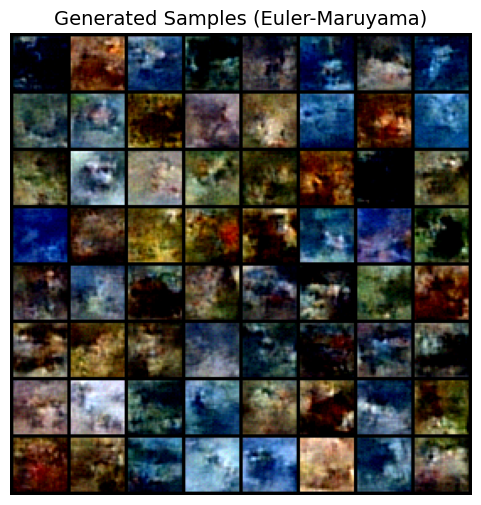

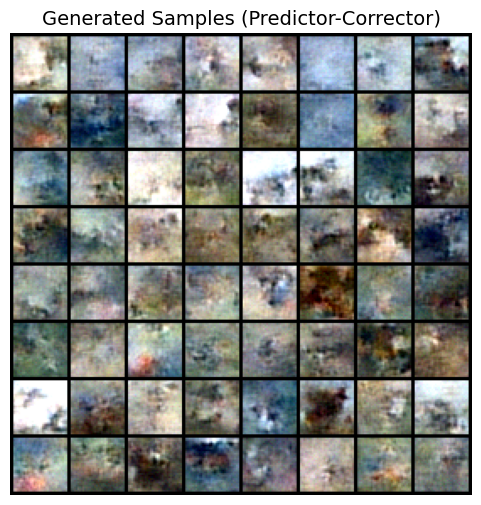

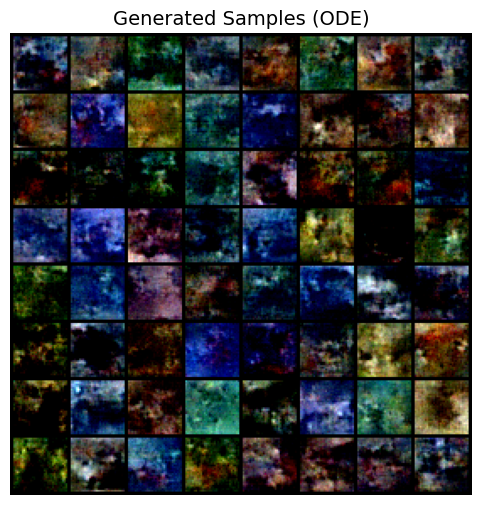

In [11]:
visualize_samples(samples_euler, 'Generated Samples (Euler-Maruyama)')
visualize_samples(samples_pc, 'Generated Samples (Predictor-Corrector)')
visualize_samples(samples_ode, 'Generated Samples (ODE)')